
Training...

step    0 | loss 3.3307
step   50 | loss 1.9820
step  100 | loss 1.4075
step  150 | loss 0.5536
step  200 | loss 0.2467
step  250 | loss 0.1594
step  300 | loss 0.1245
step  350 | loss 0.1246
step  400 | loss 0.1209
step  450 | loss 0.1189
step  500 | loss 0.1190
step  550 | loss 0.1128
step  600 | loss 0.0978
step  650 | loss 0.0955
step  700 | loss 0.1175
step  750 | loss 0.1077
step  800 | loss 0.1075
step  850 | loss 0.1073
step  900 | loss 0.1000
step  950 | loss 0.0987
step 1000 | loss 0.0857
step 1050 | loss 0.0988
step 1100 | loss 0.1337
step 1150 | loss 0.1021
step 1200 | loss 0.1011
step 1250 | loss 0.0956
step 1300 | loss 0.0951
step 1350 | loss 0.1007
step 1400 | loss 0.0960
step 1450 | loss 0.0966
step 1500 | loss 0.1056
step 1550 | loss 0.0943
step 1600 | loss 0.1057
step 1650 | loss 0.0894
step 1700 | loss 0.0991
step 1750 | loss 0.0983
step 1800 | loss 0.0929
step 1850 | loss 0.0941
step 1900 | loss 0.0867
step 1950 | loss 0.0911
step 2000 | loss 0.0969
st

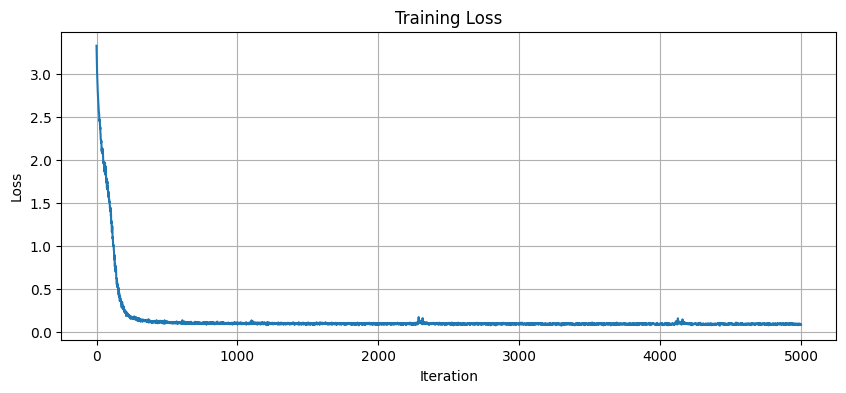

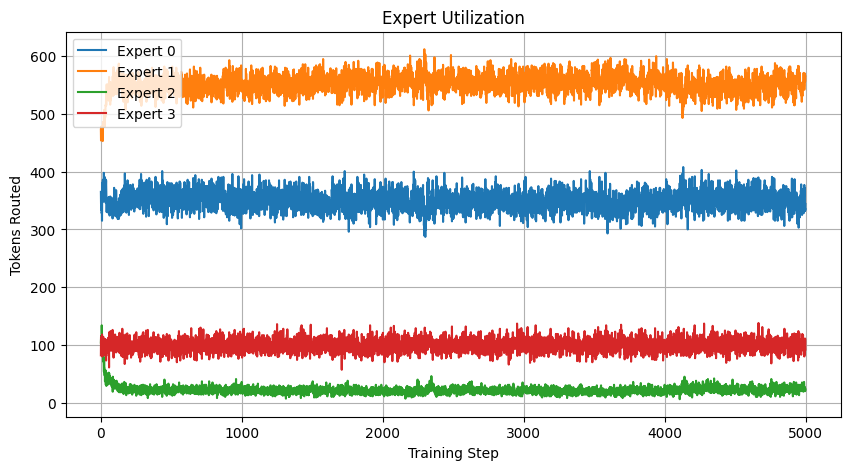

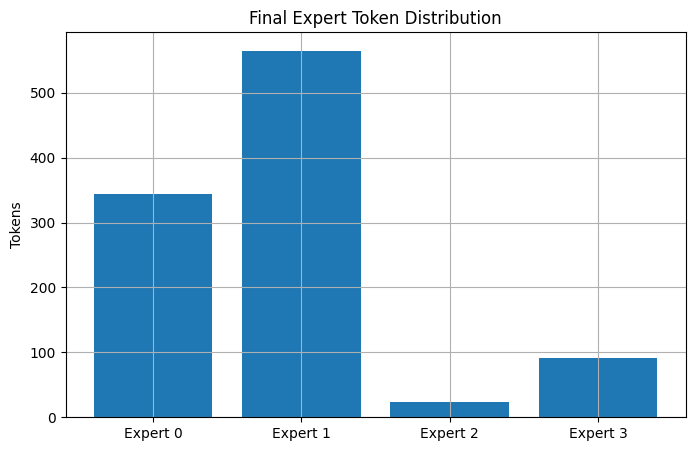


MODEL STATS
Total Parameters: 667,679
Experts: 4
Top-K Routing: 1

ROUTING ANALYSIS
Token 'n' -> Expert 1
Token ' ' -> Expert 0
Token 'm' -> Expert 1
Token 'i' -> Expert 3
Token 'x' -> Expert 1
Token 't' -> Expert 0
Token 'u' -> Expert 0
Token 'r' -> Expert 1
Token 'e' -> Expert 1
Token ' ' -> Expert 0


In [3]:
# ============================================================
# MINI TRANSFORMER COM MIXTURE OF EXPERTS (MoE)
# Implementação educacional completa em PyTorch
# ============================================================

import math
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np # Import numpy

# ============================================================
# CONFIG
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEQ_LEN = 32
BATCH_SIZE = 32
EMBED_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 2
FFN_DIM = 256

NUM_EXPERTS = 4
TOP_K = 1

VOCAB_SIZE = 80
MAX_ITERS = 5000 # Increased training iterations
LR = 3e-4

torch.manual_seed(42)

# ============================================================
# DATASET SINTÉTICO
# ============================================================

sentences = [
    "the cat sits on the mat",
    "deep learning is powerful",
    "transformers use attention",
    "mixture of experts is sparse",
    "artificial intelligence is evolving",
    "the dog runs in the park",
    "language models predict tokens",
    "routing tokens to experts",
    "sparse models scale efficiently",
    "attention mechanisms are important",
]

text = " ".join(sentences).lower()

chars = sorted(list(set(text)))

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

VOCAB_SIZE = len(chars)

encode = lambda s: [stoi[c] for c in s]
decode = lambda x: "".join([itos[i] for i in x])

data = torch.tensor(encode(text), dtype=torch.long)

# ============================================================
# BATCH
# ============================================================

def get_batch():

    ix = torch.randint(len(data) - SEQ_LEN - 1, (BATCH_SIZE,))

    x = torch.stack([data[i:i+SEQ_LEN] for i in ix])
    y = torch.stack([data[i+1:i+SEQ_LEN+1] for i in ix])

    return x.to(DEVICE), y.to(DEVICE)

# ============================================================
# POSITIONAL ENCODING
# ============================================================

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):

        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]

# ============================================================
# SELF ATTENTION
# ============================================================

class MultiHeadSelfAttention(nn.Module):

    def __init__(self, d_model, num_heads):

        super().__init__()

        assert d_model % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.qkv = nn.Linear(d_model, d_model * 3)
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x):

        B, T, C = x.shape

        qkv = self.qkv(x)

        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        mask = torch.tril(torch.ones(T, T)).to(x.device)

        attn = attn.masked_fill(mask == 0, float("-inf"))

        attn = F.softmax(attn, dim=-1)

        out = attn @ v

        out = out.transpose(1, 2).contiguous().view(B, T, C)

        out = self.proj(out)

        return out

# ============================================================
# EXPERT
# ============================================================

class Expert(nn.Module):

    def __init__(self, d_model, d_ff):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):

        return self.net(x)

# ============================================================
# ROUTER
# ============================================================

class Router(nn.Module):

    def __init__(self, d_model, num_experts):

        super().__init__()

        self.gate = nn.Linear(d_model, num_experts)

    def forward(self, x):

        logits = self.gate(x)

        probs = F.softmax(logits, dim=-1)

        return probs

# ============================================================
# MOE LAYER
# ============================================================

class MoELayer(nn.Module):

    def __init__(
        self,
        d_model,
        d_ff,
        num_experts=4,
        top_k=1
    ):

        super().__init__()

        self.num_experts = num_experts
        self.top_k = top_k

        self.experts = nn.ModuleList([
            Expert(d_model, d_ff)
            for _ in range(num_experts)
        ])

        self.router = Router(d_model, num_experts)

        self.last_expert_usage = None

    def forward(self, x):

        B, T, C = x.shape

        routing_probs = self.router(x)

        topk_probs, topk_indices = torch.topk(
            routing_probs,
            self.top_k,
            dim=-1
        )

        output = torch.zeros_like(x)

        expert_usage = torch.zeros(
            self.num_experts,
            device=x.device
        )

        for k in range(self.top_k):

            expert_idx = topk_indices[..., k]
            expert_prob = topk_probs[..., k].unsqueeze(-1)

            for i, expert in enumerate(self.experts):

                mask = (expert_idx == i)

                expert_usage[i] += mask.sum()

                if mask.any():

                    selected = x[mask]

                    expert_output = expert(selected)

                    output[mask] += expert_output * expert_prob[mask]

        self.last_expert_usage = expert_usage.detach().cpu()

        return output

# ============================================================
# TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads,
        d_ff,
        num_experts,
        top_k
    ):

        super().__init__()

        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, num_heads)

        self.ln2 = nn.LayerNorm(d_model)

        self.moe = MoELayer(
            d_model,
            d_ff,
            num_experts,
            top_k
        )

    def forward(self, x):

        x = x + self.attn(self.ln1(x))

        x = x + self.moe(self.ln2(x))

        return x

# ============================================================
# MINI TRANSFORMER
# ============================================================

class MiniTransformerMoE(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM)

        self.pos_encoding = PositionalEncoding(EMBED_DIM)

        self.blocks = nn.ModuleList([
            TransformerBlock(
                EMBED_DIM,
                NUM_HEADS,
                FFN_DIM,
                NUM_EXPERTS,
                TOP_K
            )
            for _ in range(NUM_LAYERS)
        ])

        self.ln_f = nn.LayerNorm(EMBED_DIM)

        self.head = nn.Linear(EMBED_DIM, VOCAB_SIZE)

    def forward(self, idx, targets=None):

        x = self.embedding(idx)

        x = self.pos_encoding(x)

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)

        logits = self.head(x)

        loss = None

        if targets is not None:

            B, T, C = logits.shape

            logits_flat = logits.view(B*T, C)
            targets_flat = targets.view(B*T)

            loss = F.cross_entropy(
                logits_flat,
                targets_flat
            )

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100):

        self.eval()

        for _ in range(max_new_tokens):

            idx_cond = idx[:, -SEQ_LEN:]

            logits, _ = self(idx_cond)

            logits = logits[:, -1, :]

            probs = F.softmax(logits, dim=-1)

            next_token = torch.multinomial(probs, 1)

            idx = torch.cat([idx, next_token], dim=1)

        return idx

# ============================================================
# MODEL
# ============================================================

model = MiniTransformerMoE().to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR
)

# ============================================================
# TRAINING
# ============================================================

losses = []
expert_history = []

print("\nTraining...\n")

for step in range(MAX_ITERS):

    x, y = get_batch()

    logits, loss = model(x, y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    usage = model.blocks[0].moe.last_expert_usage.numpy()

    expert_history.append(usage)

    if step % 50 == 0:

        print(f"step {step:4d} | loss {loss.item():.4f}")

# ============================================================
# GENERATION
# ============================================================

print("\n==============================")
print("TEXT GENERATION")
print("==============================\n")

context = torch.zeros((1, 1), dtype=torch.long).to(DEVICE)

generated = model.generate(
    context,
    max_new_tokens=300
)[0].tolist()

print(decode(generated))

# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(losses)

plt.title("Training Loss")

plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

# ============================================================
# EXPERT UTILIZATION
# ============================================================

# Convert expert_history to a numpy array first for efficiency
expert_history = torch.tensor(np.array(expert_history))

plt.figure(figsize=(10, 5))

for i in range(NUM_EXPERTS):

    plt.plot(
        expert_history[:, i],
        label=f"Expert {i}"
    )

plt.title("Expert Utilization")

plt.xlabel("Training Step")

plt.ylabel("Tokens Routed")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# FINAL EXPERT DISTRIBUTION
# ============================================================

final_usage = expert_history[-1]

plt.figure(figsize=(8, 5))

plt.bar(
    [f"Expert {i}" for i in range(NUM_EXPERTS)],
    final_usage.numpy()
)

plt.title("Final Expert Token Distribution")

plt.ylabel("Tokens")

plt.grid(True)

plt.show()

# ============================================================
# PARAM COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("\n==============================")
print("MODEL STATS")
print("==============================")

print(f"Total Parameters: {total_params:,}")
print(f"Experts: {NUM_EXPERTS}")
print(f"Top-K Routing: {TOP_K}")

# ============================================================
# ANALISAR ROUTING
# ============================================================

print("\n==============================")
print("ROUTING ANALYSIS")
print("==============================")

x, _ = get_batch()

with torch.no_grad():

    embed = model.embedding(x)

    embed = model.pos_encoding(embed)

    router_probs = model.blocks[0].moe.router(embed)

    top_experts = router_probs.argmax(dim=-1)

for i in range(10):

    token_id = x[0, i].item()

    token_char = itos[token_id]

    expert = top_experts[0, i].item()

    print(
        f"Token '{token_char}' "
        f"-> Expert {expert}"
    )